## 🛍️ Customer Segmentation using K-Means Clustering

### 🎯 Project Objective

Developed a customer segmentation model using unsupervised machine learning techniques to identify distinct customer groups based on demographic and spending behavior attributes. The project focuses on discovering hidden customer patterns, generating customer personas, and deriving actionable business insights to support targeted marketing strategies.

### 🚀 Key Highlights

* Conducted Exploratory Data Analysis (EDA) to analyze customer demographics and purchasing behavior.
* Applied K-Means Clustering to identify meaningful customer segments.
* Determined the optimal number of clusters using the Elbow Method.
* Visualized customer groups through data-driven analytical plots.
* Explored Hierarchical Clustering for comparative segmentation analysis.
* Generated customer personas and business recommendations from cluster insights.

### 🛠️ Tech Stack

**Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-Learn | K-Means Clustering | Hierarchical Clustering**



#### 🤖 Understanding Unsupervised Learning

Unlike supervised learning, unsupervised learning does not rely on predefined target labels. Instead, it focuses on discovering hidden patterns and relationships within the data.

In this project, clustering techniques are used to identify customer groups with similar demographic and spending behaviors. These customer segments help uncover meaningful insights that can support business decision-making and targeted marketing strategies.


---
### Step 1: Setup - Importing Libraries and Loading Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

In [2]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 5.7 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.9 MB 4.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 4.4 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/9.9 MB 4.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 4.2 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 4.2 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 4.1 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 4.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 4.0 MB/s eta 0:00:01
   ---------------------

### 🎯 K-Means Clustering

K-Means Clustering was applied to group customers with similar demographic and spending characteristics. The algorithm partitions data into distinct clusters by minimizing the distance between data points and their respective cluster centroids. This approach enables the identification of meaningful customer segments for behavioral analysis and business decision-making.


In [5]:
# Load the customer dataset

df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully.")
print(f"Dataset Shape: {df.shape}")

df.head()


Dataset loaded successfully.
Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


---
### 📊 Step 2: Exploratory Data Analysis (EDA)

Exploratory data analysis was performed to examine customer demographics, spending patterns, and feature relationships prior to the clustering process.


In [6]:
# Explore dataset structure
print("Dataset Info:")
df.info()

# Drop CustomerID column
df.drop('CustomerID', axis=1, inplace=True)

print("\nDescriptive Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Descriptive Statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.

#### 2.1 Univariate Analysis (Feature Distributions)

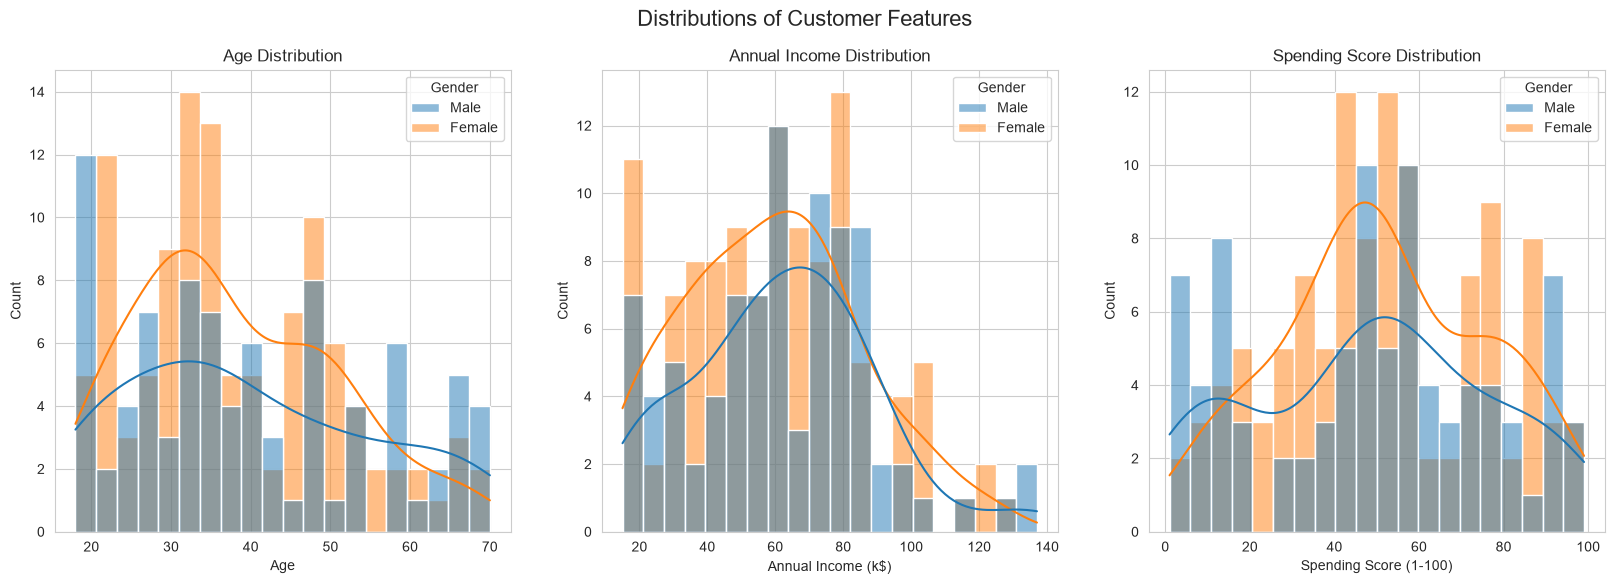

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distributions of Customer Features', fontsize=16)

sns.histplot(ax=axes[0], data=df, x='Age', kde=True, bins=20, hue='Gender').set_title('Age Distribution')
sns.histplot(ax=axes[1], data=df, x='Annual Income (k$)', kde=True, bins=20, hue='Gender').set_title('Annual Income Distribution')
sns.histplot(ax=axes[2], data=df, x='Spending Score (1-100)', kde=True, bins=20, hue='Gender').set_title('Spending Score Distribution')

plt.show()

#### 2.2 Bivariate Analysis (Looking for Relationships)

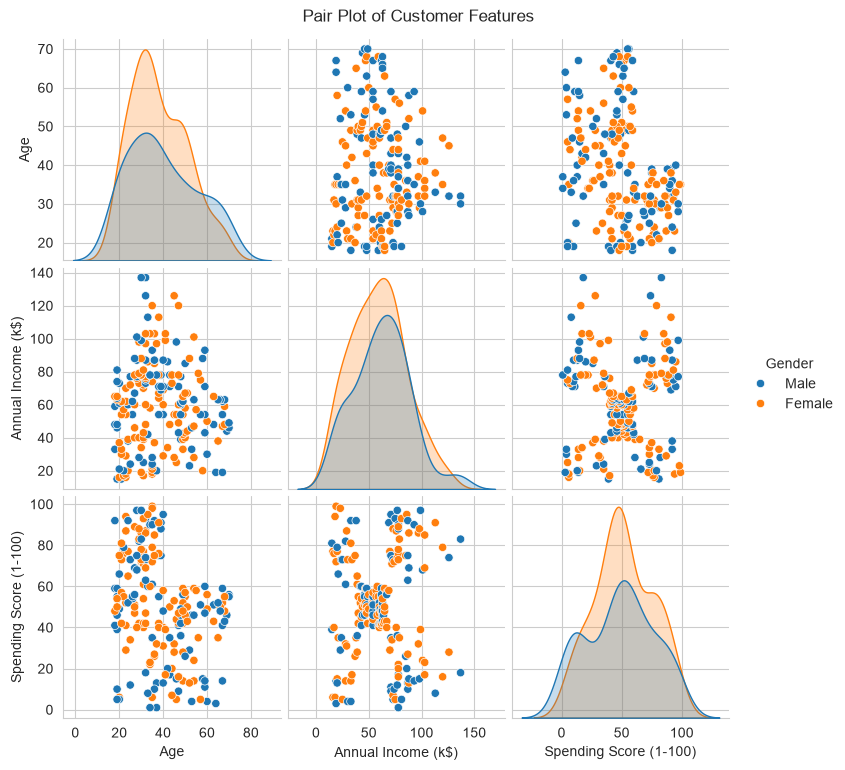

In [ ]:
# Visualize relationships between customer attributes using a pair plot
sns.pairplot(df, vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], hue='Gender', diag_kind='kde')
plt.suptitle('Pair Plot of Customer Features', y=1.02)
plt.show()

 #### 🔍 Key Observations

 - The relationship between **Annual Income** and **Spending Score** reveals distinct customer groups, indicating strong potential for customer segmentation through clustering techniques.

 - The **Age vs Spending Score** distribution suggests that higher spending behavior is more commonly observed among younger customers, although the pattern is less pronounced.

 - **Gender** does not exhibit a significant influence on customer segmentation, as the distributions of male and female customers show substantial overlap across the analyzed features.

#### 🌐 2.3 Three-Dimensional Feature Visualization

A 3D visualization was created to examine the combined relationship between **Age**, **Annual Income**, and **Spending Score**. This multidimensional view provides deeper insights into customer behavior patterns and helps assess the potential separation of customer groups before applying clustering techniques.

In [21]:
fig = px.scatter_3d(df,
                    x='Annual Income (k$)',
                    y='Spending Score (1-100)',
                    z='Age',
                    color='Gender',
                    title='3D View of Customer Data')
import plotly.io as pio

pio.renderers.default = "browser"

fig.show()

---
### Step 3: Segmentation Model 1 - Income & Spending Score

This primary segmentation model utilizes the most relevant features identified during exploratory data analysis for effective customer grouping.


#### 📉 Determining the Optimal Number of Clusters

The Elbow Method was applied to identify the optimal number of customer segments for clustering. This technique evaluates the Within-Cluster Sum of Squares (WCSS) across different values of *k* and helps determine the point at which increasing the number of clusters provides minimal additional improvement. The selected cluster count ensures an effective balance between segmentation quality and model simplicity.

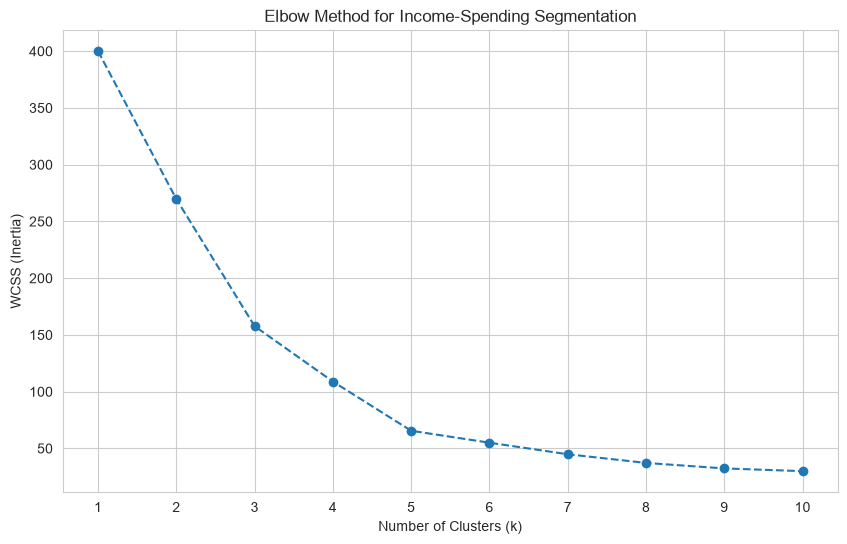

In [23]:
# Select and scale clustering features
X1 = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# Compute WCSS values
wcss1 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X1_scaled)
    wcss1.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss1, marker='o', linestyle='--')
plt.title('Elbow Method for Income-Spending Segmentation')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

### 🔍 Key Observation

The Elbow Curve indicates a clear elbow point at **k = 5**. The WCSS value decreases significantly up to five clusters and then begins to stabilize. Therefore, **five clusters** were selected as the optimal number of customer segments for further analysis.

#### 🎯 Building the Final Clustering Model

The K-Means algorithm was trained using the optimal number of clusters identified through the Elbow Method. Each customer was assigned to a cluster based on similarities in annual income and spending behavior.

In [25]:
# Train the final K-Means clustering model
kmeans1 = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# Assign cluster labels to each customer
df['Income_Cluster'] = kmeans1.fit_predict(X1_scaled)

### 3.1 Visualizing and Interpreting the Income-Based Segments

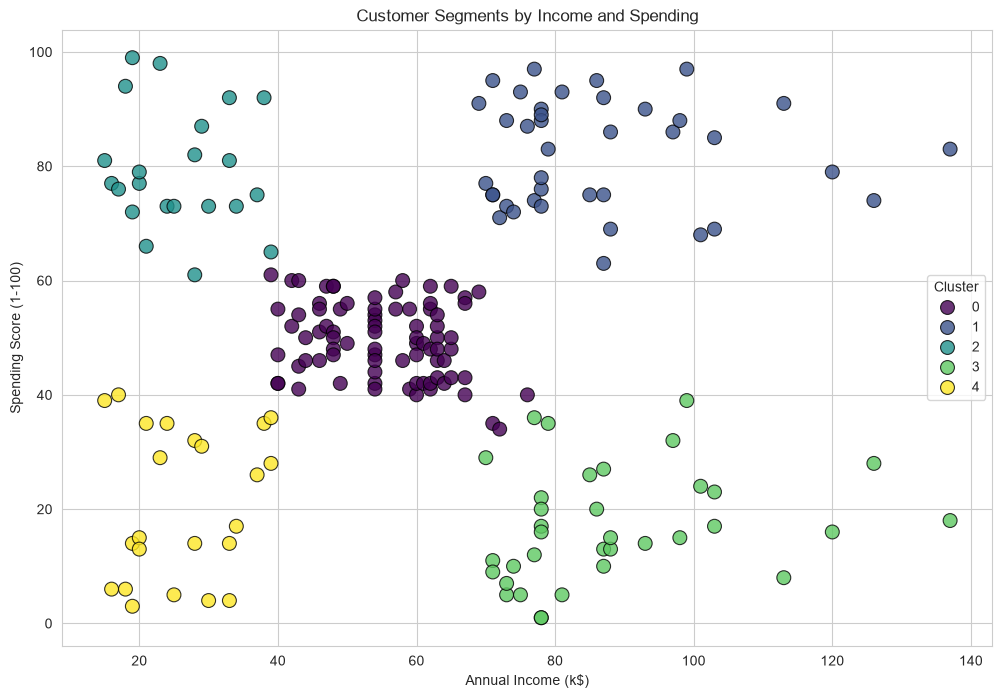

In [26]:
# Visualize customer segments

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Income_Cluster',
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='black'
)

plt.title('Customer Segments by Income and Spending')
plt.legend(title='Cluster')
plt.show()

In [27]:
# Quantitative Persona Analysis
cluster_profiles1 = df.groupby('Income_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_profiles1['Size'] = df['Income_Cluster'].value_counts()
print("--- Income-Based Cluster Profiles ---")
cluster_profiles1

--- Income-Based Cluster Profiles ---


,Age,Annual Income (k$),Spending Score (1-100),Size
Income_Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


### 3.2 Income-Based Personas and Business Insights

Using the cluster profiles, the following customer segments were identified:

• **Cluster 0 – Standard Customers**
  Moderate income (~55k) and average spending (~50). Represents the largest customer segment and forms the core customer base.

• **Cluster 1 – High-Value Customers**
  High income (~87k) and high spending (~82). Premium customers with strong purchasing power and high revenue potential.

• **Cluster 2 – Aspirational Shoppers**
  Lower income (~26k) but high spending (~79). Younger and trend-oriented customers who demonstrate strong purchasing behavior despite lower income levels.

• **Cluster 3 – Conservative Affluent Customers**
  High income (~88k) but low spending (~17). Financially capable customers who spend selectively and focus on value.

• **Cluster 4 – Budget-Conscious Customers**
  Lower income (~26k) and low spending (~21). Price-sensitive customers with limited purchasing activity.

---
### Step 4: Segmentation Model 2 - Age & Spending Score

This segmentation model focuses on **Age** and **Spending Score** to identify distinct customer groups based on purchasing behavior across different age categories.


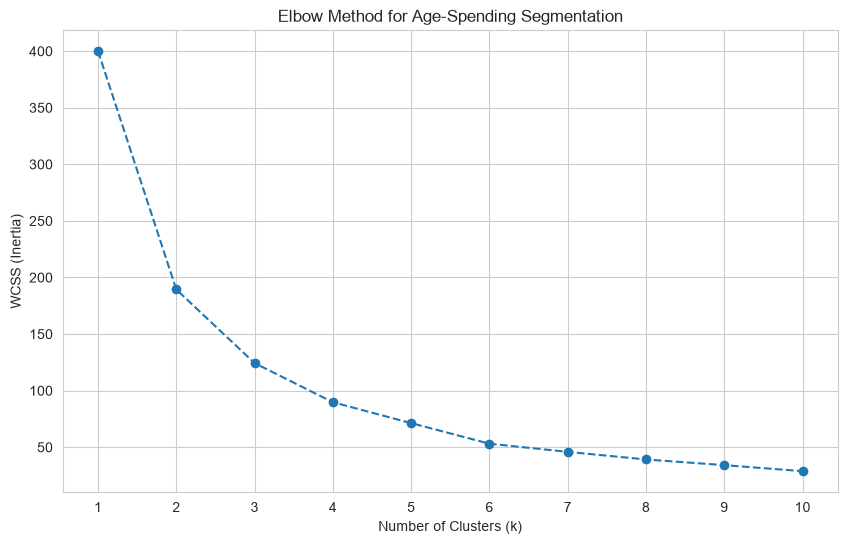

In [28]:
# Select and standardize features
X2 = df[['Age', 'Spending Score (1-100)']]
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Compute WCSS values
wcss2 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X2_scaled)
    wcss2.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss2, marker='o', linestyle='--')
plt.title('Elbow Method for Age-Spending Segmentation')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

### 🔍 Observation

The Elbow Curve suggests that **k = 5** provides a reasonable balance between cluster compactness and model complexity. Beyond five clusters, the reduction in WCSS becomes less significant, indicating diminishing returns from adding additional clusters.


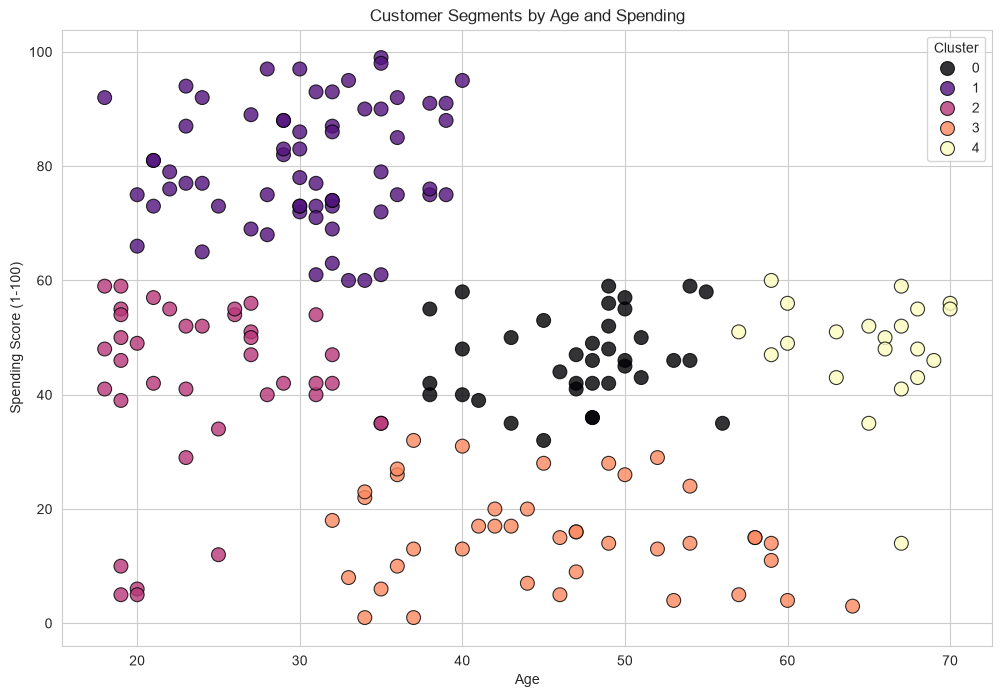

In [30]:
# Train the age-based clustering model
kmeans2 = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Age_Cluster'] = kmeans2.fit_predict(X2_scaled)

# Visualize customer segments
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)',
                hue='Age_Cluster', palette='magma', s=100, alpha=0.8, edgecolor='black')
plt.title('Customer Segments by Age and Spending')
plt.legend(title='Cluster')
plt.show()

#### 4.1 Interpreting the Age-Based Segments

This model reveals distinct customer groups based on age and spending behavior:

- **Young High-Spenders:** Customers in the younger age group (approximately 18-40 years) exhibiting consistently high spending scores.

- **Young Moderate-Spenders:** Younger customers with moderate spending behavior, representing a balanced purchasing pattern.

- **Middle-Aged Average-Spenders:** Customers between 40-60 years with relatively stable and average spending scores.

- **Middle-Aged Low-Spenders:** Customers within the middle-age category showing low spending activity despite being active shoppers.

- **Senior Moderate-Spenders:** Older customers (above 60 years) demonstrating moderate spending habits and forming a separate customer segment.

---
### Step 5: Hierarchical Clustering

To validate the clustering results obtained from K-Means, Hierarchical Clustering was applied as an alternative segmentation approach. A dendrogram was used to analyze cluster relationships and evaluate the optimal number of customer groups.

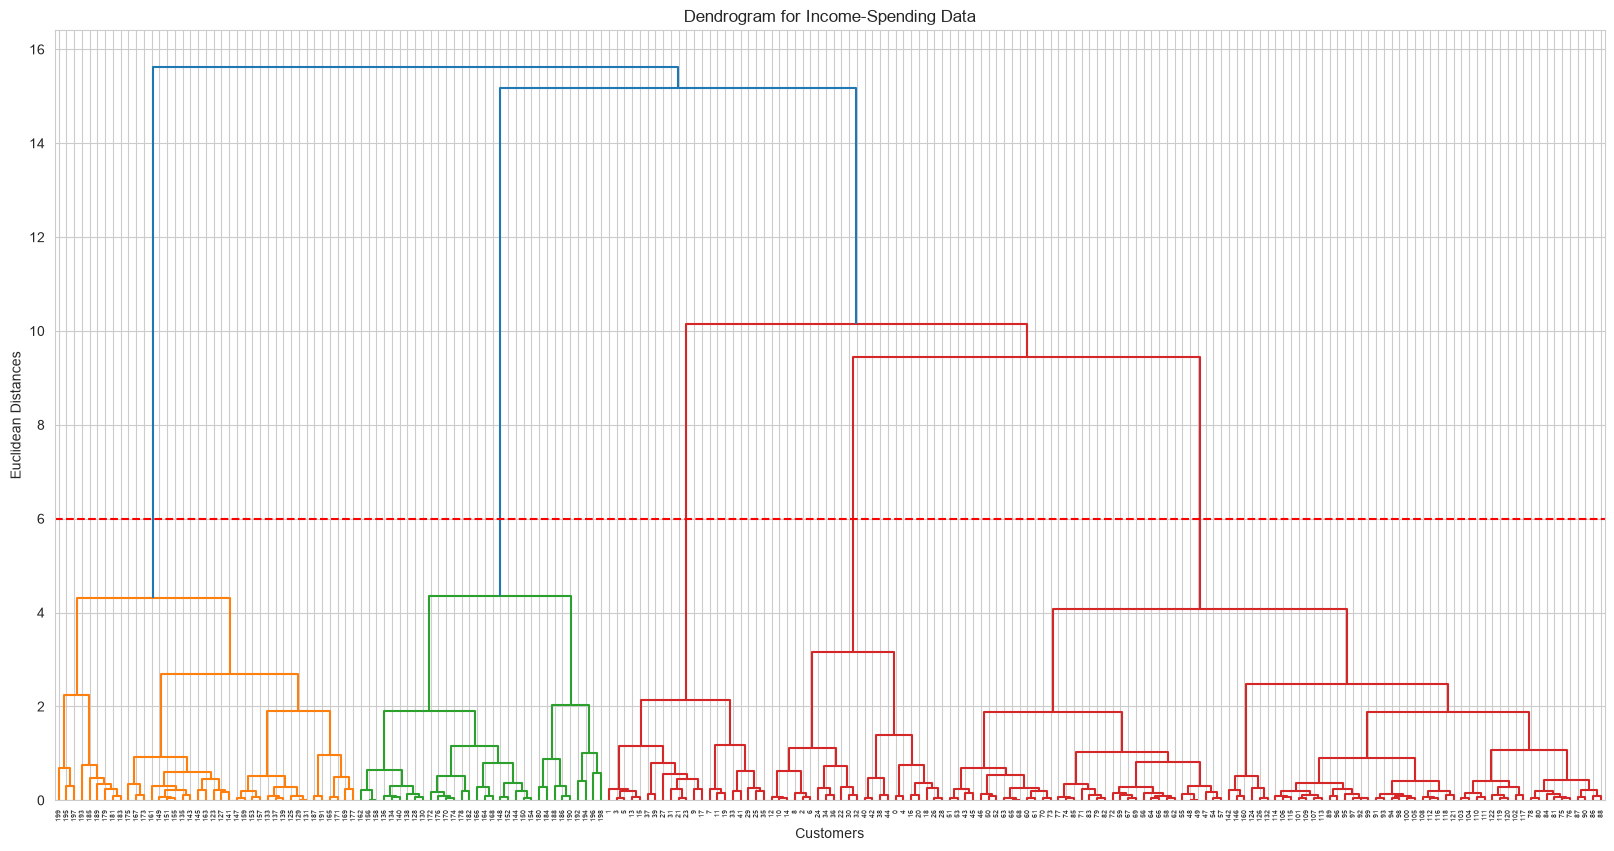

In [ ]:
plt.figure(figsize=(20, 10))
dendrogram = sch.dendrogram(sch.linkage(X1_scaled, method='ward'))
plt.title('Dendrogram for Income-Spending Data')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.axhline(y=6, color='r', linestyle='--') 
plt.show()

**Insight:** The dendrogram also confirms that **5 clusters** is the optimal number for the income-spending data. If we draw a horizontal line at a height of 6 (as shown by the red dashed line), it crosses five vertical lines.

In [35]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)

df['Hierarchical_Cluster'] = hc.fit_predict(X1_scaled)

print(df[['Annual Income (k$)',
          'Spending Score (1-100)',
          'Hierarchical_Cluster']])

     Annual Income (k$)  Spending Score (1-100)  Hierarchical_Cluster
0                    15                      39                     4
1                    15                      81                     3
2                    16                       6                     4
3                    16                      77                     3
4                    17                      40                     4
..                  ...                     ...                   ...
195                 120                      79                     1
196                 126                      28                     0
197                 126                      74                     1
198                 137                      18                     0
199                 137                      83                     1

[200 rows x 3 columns]


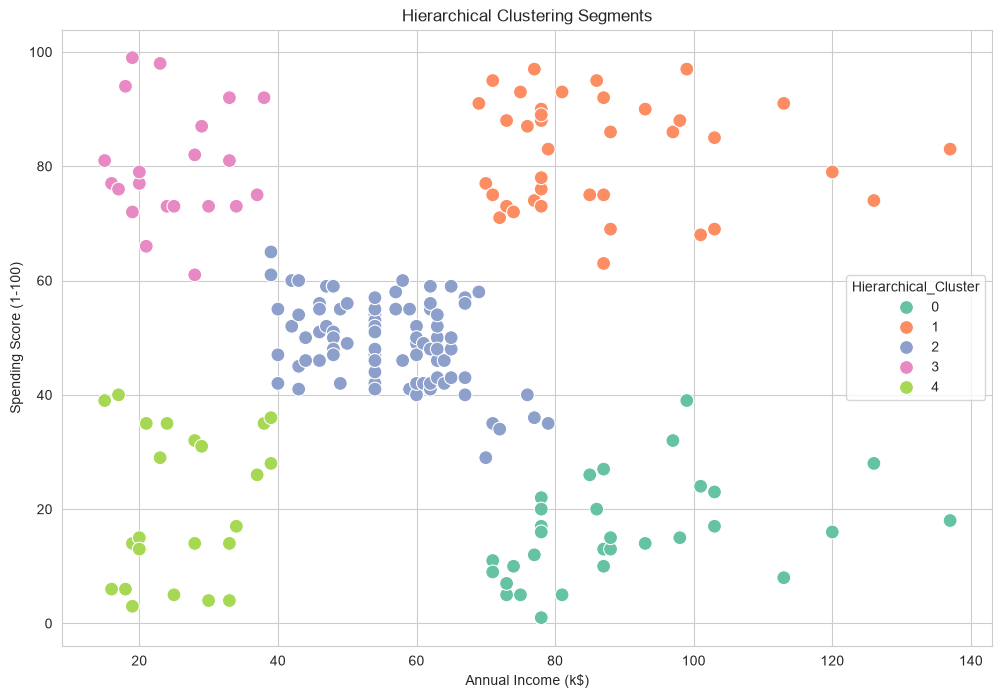

In [36]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Hierarchical_Cluster',
    palette='Set2',
    s=100
)

plt.title('Hierarchical Clustering Segments')
plt.show()

#### 🔍 Insight

The Hierarchical Clustering model identified five distinct customer segments based on Annual Income and Spending Score. The clusters clearly separate customers into high-spending and low-spending groups across different income levels. High-income customers are divided into both premium spenders and cautious spenders, while low-income customers are similarly split between enthusiastic and budget-conscious shoppers. The central cluster represents customers with moderate income and average spending behavior. These results closely align with the K-Means clustering output, reinforcing the reliability of the identified customer segments.

---
### Step 6. Gender vs Spending Score Analysis

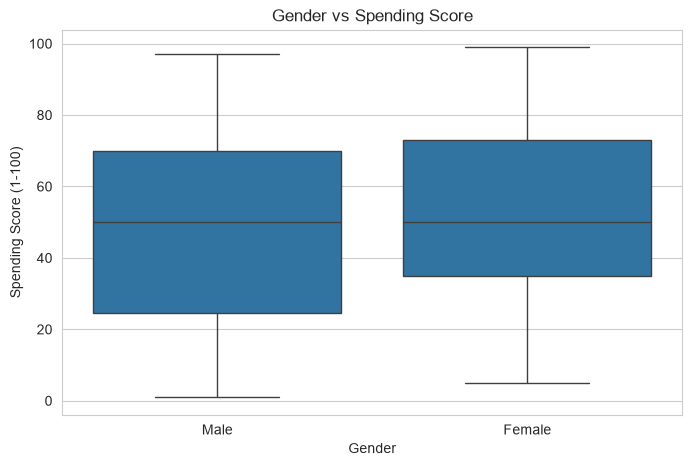

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)')
plt.title('Gender vs Spending Score')
plt.show()

### 🔍 Observation

The spending score distributions for male and female customers are highly similar, with nearly identical median values and overlapping ranges. This suggests that gender has little influence on customer spending behavior and is not a strong feature for customer segmentation.

--- 
### Step 7: Feature Engineering for Clustering

A new feature was created by combining existing variables to better capture customer spending behavior. This engineered feature provides additional insights and helps evaluate whether clustering performance can be improved using derived customer characteristics.

#### 7.1 Creating an Engineered Feature

In [39]:
# Create a spending efficiency feature

df['Spending_Efficiency'] = (
    df['Spending Score (1-100)'] /
    df['Annual Income (k$)']
).round(2)

df[['Annual Income (k$)',
    'Spending Score (1-100)',
    'Spending_Efficiency']].head()

,Annual Income (k$),Spending Score (1-100),Spending_Efficiency
0,15,39,2.60
1,15,81,5.40
2,16,6,0.38
3,16,77,4.81
4,17,40,2.35


#### 7.2 Clustering Using the Engineered Feature

The engineered feature was combined with Annual Income to create a new clustering dataset. Feature scaling was applied before evaluating the optimal number of clusters.

In [40]:
# Select and scale engineered features

X3 = df[['Annual Income (k$)', 'Spending_Efficiency']]

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

#### 7.3 Determining the Optimal Number of Clusters

The Elbow Method was used to identify the optimal cluster count for the engineered feature dataset.

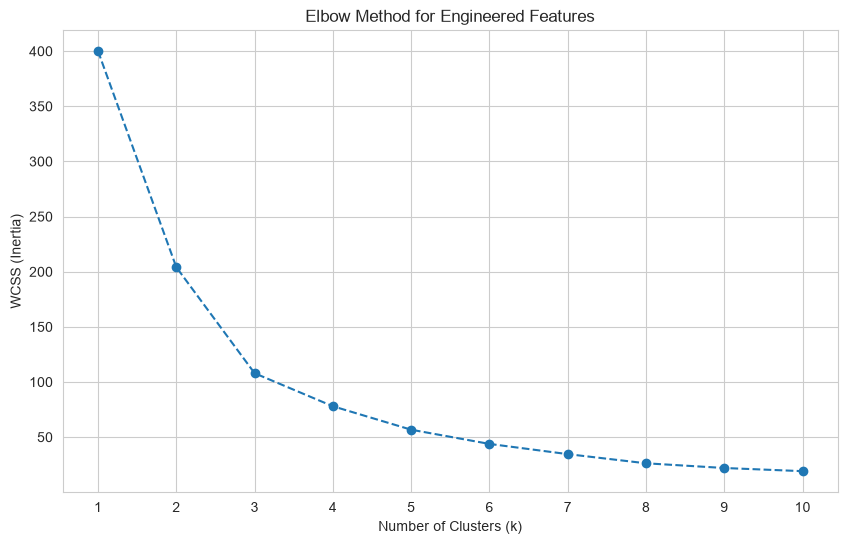

In [42]:
# Compute WCSS values

wcss3 = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X3_scaled)
    wcss3.append(kmeans.inertia_)

# Plot the elbow curve

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss3, marker='o', linestyle='--')
plt.title('Elbow Method for Engineered Features')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

### 🔍 Observation

The Elbow Curve indicates a noticeable reduction in WCSS up to k = 5. Beyond this point, the rate of improvement becomes relatively small, suggesting diminishing returns from adding more clusters. Therefore, five clusters were selected as the optimal number for the engineered feature segmentation model.

#### 7.4 Building the Final Clustering Model

In [43]:
# Train the clustering model

kmeans3 = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['Efficiency_Cluster'] = kmeans3.fit_predict(X3_scaled)

#### 7.5 Visualizing the Engineered Feature Segments

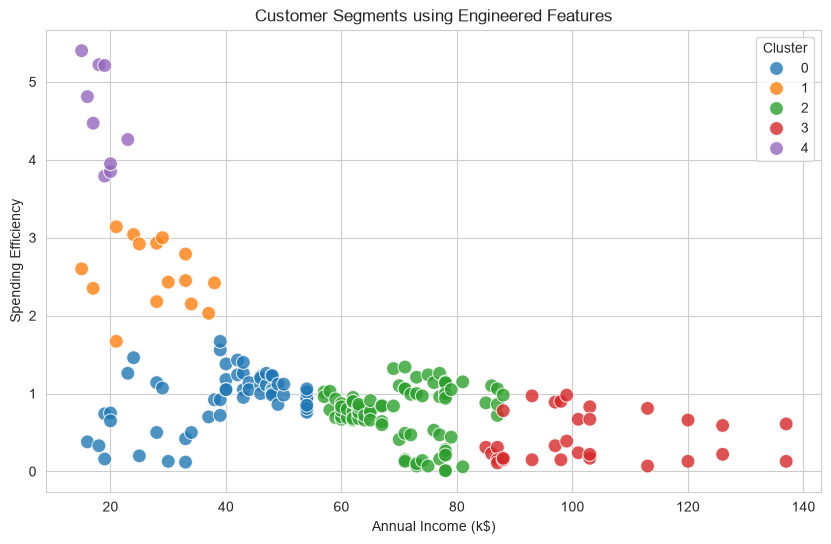

In [44]:
# Visualize engineered feature clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending_Efficiency',
    hue='Efficiency_Cluster',
    palette='tab10',
    s=100,
    alpha=0.8
)

plt.title('Customer Segments using Engineered Features')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Efficiency')
plt.legend(title='Cluster')

plt.show()

### 🔍 Observation

The engineered feature created well-separated customer segments based on spending efficiency and income levels. Customers with lower income and high spending behavior appear in clusters with high spending efficiency, while higher-income customers are grouped into clusters with relatively lower efficiency values. The clear separation between clusters indicates that the engineered feature provides additional discriminatory power and enhances customer segmentation beyond the original variables.

### Step 8: Conclusion

In this project, multiple clustering techniques were applied to perform customer segmentation and analyze customer behavior patterns.

### Key Steps Undertaken:

1. **Performed Exploratory Data Analysis (EDA):** Used statistical summaries and visualizations to identify key patterns and relationships within the dataset.

2. **Developed Income-Based and Age-Based Segmentation Models:** Applied K-Means clustering using different feature combinations to uncover distinct customer groups.

3. **Determined the Optimal Number of Clusters:** Utilized the Elbow Method to select the most appropriate cluster count for each segmentation model.

4. **Validated Results Using Hierarchical Clustering:** Generated a dendrogram and compared the clustering structure with K-Means results.

5. **Analyzed Gender-Based Spending Behavior:** Examined the relationship between gender and spending score, finding minimal differences between customer groups.

6. **Applied Feature Engineering:** Created a new feature, **Spending Efficiency**, and successfully incorporated it into the clustering process to improve customer segmentation.

7. **Generated Actionable Customer Segments:** Identified meaningful customer groups that can support targeted marketing strategies and business decision-making.

This project demonstrates how clustering techniques, combined with exploratory analysis and feature engineering, can transform raw customer data into valuable business insights and support data-driven decision-making.